# Relatório do Laboratório 4 — Calibração de Câmeras

### ESZA019 — Visão Computacional · UFABC · 2026.2

---

**Autores:**

| # | Nome completo | RA |
|---|---------------|----|
| 1 | *Antonio Carlos de Freitas Vidal Junior* | *11201920894* |
| 2 | *João Vitor De Oliveira Lamano* | *11202022114* |
| 3 | *Willian Kenji Takaracy* | *11201812251* |


## 1. Introdução

Toda câmera transforma o mundo tridimensional em uma imagem bidimensional, e essa
transformação nunca é perfeita: a lente introduz **distorções** e a geometria
interna do sensor determina como os pontos do espaço "caem" sobre os pixels.
**Calibrar uma câmera** é justamente descobrir, de forma numérica, os parâmetros
que descrevem esse processo — algo essencial em Visão Computacional para qualquer
tarefa que exija medidas confiáveis, como reconstrução 3D, visão estéreo,
realidade aumentada e robótica.

Neste quarto laboratório, o objetivo foi entender e obter na prática os
**parâmetros intrínsecos** (próprios da câmera + lente) e **extrínsecos** (a pose
da câmera em relação à cena) por meio do método clássico do **tabuleiro de xadrez**
(*checkerboard*) implementado no OpenCV. Fotografamos um padrão de tabuleiro em
várias posições e, a partir da correspondência entre os cantos detectados na
imagem e suas coordenadas conhecidas no mundo, o OpenCV estima a **matriz da
câmera K**, os **coeficientes de distorção**, e as **rotações e translações**
de cada vista.

O relatório está organizado assim: uma **fundamentação teórica** sobre o modelo de
câmera *pinhole*, os parâmetros intrínsecos/extrínsecos e a distorção de lente; os
**procedimentos experimentais**, divididos exatamente nos quatro itens do roteiro —
(A) calibração com imagens de exemplo fornecidas, (B) calibração da nossa própria
**webcam**, (C) calibração de uma **segunda câmera pessoal** (celular) e (D)
**correção de distorção** de imagens; e, por fim, a **análise e discussão**, onde
respondemos às perguntas do roteiro (significado de K, R, t e dist; cálculo de
*focal length*, *aspect ratio*, *skew* e *principal point*; o porquê de um par R,t
por imagem; e a comparação entre as câmeras).


## 2. Fundamentação Teórica

### 2.1 O modelo de câmera *pinhole*

O modelo mais usado para descrever uma câmera é o **pinhole** (câmera de furo).
Nele, um ponto 3D do mundo é projetado em linha reta até o plano da imagem,
passando por um único ponto (o centro óptico). Matematicamente, a projeção de um
ponto do mundo $(X, Y, Z)$ para um pixel $(u, v)$ combina dois blocos de
parâmetros — os **intrínsecos** e os **extrínsecos**:

$$
s \begin{bmatrix} u \\ v \\ 1 \end{bmatrix}
= \underbrace{\begin{bmatrix} f_x & s_k & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}}_{K \;(\text{intrínsecos})}
\;\underbrace{\big[\, R \mid t \,\big]}_{\text{extrínsecos}}
\begin{bmatrix} X \\ Y \\ Z \\ 1 \end{bmatrix}
$$

### 2.2 Parâmetros intrínsecos — a matriz K

A **matriz da câmera K** (também chamada de matriz intrínseca) descreve a "óptica
interna" e **não depende da cena**. Seus elementos são:

- $f_x, f_y$ — as **distâncias focais** expressas em **pixels** (a distância focal
  física dividida pelo tamanho do pixel em cada direção);
- $c_x, c_y$ — o **ponto principal** (*principal point*), ou seja, onde o eixo
  óptico fura o sensor (idealmente perto do centro da imagem);
- $s_k$ — o **skew** (cisalhamento), que mede o quanto os eixos dos pixels fogem de
  90°; em sensores modernos é praticamente **zero**.

A partir de K definem-se dois números úteis: a **razão de aspecto** (*aspect
ratio*), $f_y/f_x$, que indica se o pixel é quadrado (valor ≈ 1), e o próprio
*principal point*.

### 2.3 Parâmetros extrínsecos — R e t

Enquanto K é fixo, os **extrínsecos** mudam a cada foto, porque descrevem **onde a
câmera está em relação ao objeto**:

- $R$ — a **matriz de rotação** ($3\times 3$), que orienta o sistema de coordenadas
  do mundo (fixado no tabuleiro) em relação ao sistema da câmera;
- $t$ — o **vetor de translação** ($3\times 1$), que dá a posição da origem do
  mundo vista pela câmera (basicamente, a que distância e direção o tabuleiro
  está).

Juntos, $[R \mid t]$ formam a **pose** da câmera para aquela imagem. Vale notar que
o OpenCV retorna a rotação de forma compacta como um **vetor de Rodrigues**
(`rvecs`), que pode ser convertido na matriz $R$ completa com `cv2.Rodrigues()`.

### 2.4 Distorção de lente (dist)

Nenhuma lente real é um *pinhole* perfeito: ela curva os raios, e linhas retas do
mundo aparecem levemente curvadas na imagem. O OpenCV modela isso com um vetor de
**coeficientes de distorção** $(k_1, k_2, p_1, p_2, k_3)$:

- **Distorção radial** ($k_1, k_2, k_3$): faz a imagem "inchar" (*barrel*) ou
  "afundar" (*pincushion*) em direção às bordas — é a mais visível em webcams e
  lentes grande-angulares;
- **Distorção tangencial** ($p_1, p_2$): surge quando a lente não está perfeitamente
  paralela ao sensor.

Conhecendo esses coeficientes (mais K), é possível **desfazer** a distorção e obter
uma imagem geometricamente correta — exatamente o que faremos no item (D).

### 2.5 Como o tabuleiro permite calibrar

O padrão de xadrez é útil porque seus cantos internos formam uma grade de pontos
com **coordenadas 3D conhecidas** (regularmente espaçadas em um plano, com $Z=0$).
Detectando esses mesmos cantos na imagem (`cv2.findChessboardCorners` +
`cv2.cornerSubPix` para refinar), obtemos pares "ponto do mundo ↔ pixel". Com
várias fotos do tabuleiro em posições diferentes, a função
`cv2.calibrateCamera` resolve o sistema e devolve $K$, os coeficientes de
distorção e um par $(R, t)$ para **cada** imagem.


## 3. Procedimentos experimentais

Os experimentos foram executados em **Linux**, dentro do ambiente **Conda**
(`CV26`) com **Python** e **OpenCV**, seguindo os programas fornecidos no Lab 4
(`L4_cal.py` para calibrar e `L4_chess.py` para capturar as imagens do tabuleiro).
O padrão de calibração usado tem **(6, 8)** cantos internos (`CHECKERBOARD = (6,8)`),
conforme a observação do roteiro. As próximas seções trazem os quatro itens (A–D),
com os códigos efetivamente usados (sem alterações) e a explicação de cada etapa.


### 3.1 Item (A) — Calibração com as imagens de exemplo fornecidas

Neste item rodamos a rotina de calibração sobre o **conjunto de imagens de exemplo**
que acompanha o Lab 4 (arquivos `left*.jpg`), reproduzindo o exemplo da referência
[2]. Começamos importando as bibliotecas e definindo os parâmetros do tabuleiro e
as coordenadas 3D do mundo (os cantos regularmente espaçados).

In [1]:
import cv2
import numpy as np
import os
import glob


In [2]:
# Defining the dimensions of checkerboard
CHECKERBOARD = (6,8)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
 
# Creating vector to store vectors of 3D points for each checkerboard image
objpoints = []
# Creating vector to store vectors of 2D points for each checkerboard image
imgpoints = [] 
 
 
# Defining the world coordinates for 3D points
objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0,:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
prev_img_shape = None

Em seguida, percorremos todas as imagens, detectamos os cantos do tabuleiro com
`cv2.findChessboardCorners`, refinamos com precisão subpixel (`cv2.cornerSubPix`) e
acumulamos os pares de pontos 3D↔2D. Os cantos detectados são desenhados sobre cada
imagem para conferência visual.

In [ ]:
# Extracting path of individual image stored in a given directory
images = glob.glob('left*.jpg')
for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    # Find the chess board corners
    # If desired number of corners are found in the image then ret = true
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)
     
    """
    If desired number of corner are detected,
    we refine the pixel coordinates and display 
    them on the images of checker board
    """
    if ret == True:
        objpoints.append(objp)
        # refining pixel coordinates for given 2d points.
        corners2 = cv2.cornerSubPix(gray, corners, (11,11),(-1,-1), criteria)
         
        imgpoints.append(corners2)
 
        # Draw and display the corners
        img = cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)
     
    cv2.imshow('img',img)
    cv2.waitKey(0)
 
cv2.destroyAllWindows()

Por fim, `cv2.calibrateCamera` estima os parâmetros a partir de todos os pares
acumulados e imprimimos a matriz da câmera, os coeficientes de distorção e os
vetores de rotação/translação de cada imagem.

In [4]:
h,w = img.shape[:2]
 
"""
Performing camera calibration by 
passing the value of known 3D points (objpoints)
and corresponding pixel coordinates of the 
detected corners (imgpoints)
"""
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
 
print("Camera matrix : \n")
print(mtx)
print("dist : \n")
print(dist)
print("rvecs : \n")
print(rvecs)
print("tvecs : \n")
print(tvecs)

Camera matrix : 

[[533.04084251   0.         341.99105249]
 [  0.         533.06631837 234.2493197 ]
 [  0.           0.           1.        ]]
dist : 

[[-2.80583459e-01  3.03975668e-02  1.13380661e-03  3.35420263e-05
   1.48375567e-01]]
rvecs : 

(array([[0.09938428],
       [0.2769208 ],
       [1.55844602]]), array([[0.70142995],
       [0.15653853],
       [0.16198773]]), array([[ 0.04971804],
       [-0.60067778],
       [-0.18373359]]), array([[-0.10508862],
       [ 0.3199036 ],
       [ 0.31447873]]), array([[-0.34849292],
       [-0.06837808],
       [-1.20056146]]), array([[0.06243801],
       [0.45029205],
       [0.10740232]]), array([[ 0.49751925],
       [ 0.12039045],
       [-0.29636763]]), array([[-0.37696537],
       [ 0.0689496 ],
       [-0.01940626]]), array([[-0.35546604],
       [ 0.24061581],
       [ 0.20940337]]), array([[-0.47598668],
       [ 0.08949178],
       [-0.22581819]]), array([[ 0.19392527],
       [-0.41948722],
       [-0.19433804]]), array([[ 0

**Resultados do item (A).** A calibração usou **12 imagens** de exemplo. Os
parâmetros obtidos, nas formas pedidas pelo roteiro (matriz $K$, matriz $R$, vetor
$t$ e vetor $dist$), foram:

**Matriz da câmera $K$:**

$$
K = \begin{bmatrix} 533{,}04 & 0 & 341{,}99 \\ 0 & 533{,}07 & 234{,}25 \\ 0 & 0 & 1 \end{bmatrix}
$$

**Coeficientes de distorção $dist = (k_1, k_2, p_1, p_2, k_3)$:**

$$
dist = \begin{bmatrix} -0{,}2806 & 0{,}0304 & 0{,}00113 & 0{,}0000335 & 0{,}1484 \end{bmatrix}
$$

**Extrínsecos** — há um par $(R, t)$ por imagem (12 no total). O código imprime a
rotação como vetor de Rodrigues; convertendo o da **1ª imagem** com
`cv2.Rodrigues()`, temos a matriz $R$ e o vetor $t$ correspondentes:

$$
R_1 \approx \begin{bmatrix} -0{,}011 & -0{,}971 & 0{,}237 \\ 0{,}994 & 0{,}016 & 0{,}112 \\ -0{,}112 & 0{,}237 & 0{,}965 \end{bmatrix},
\qquad
t_1 \approx \begin{bmatrix} 3{,}841 \\ -2{,}786 \\ 11{,}274 \end{bmatrix}
$$

**Significado de cada parâmetro:**

- **$K$ (matriz intrínseca):** descreve a óptica interna da câmera — distâncias
  focais em pixels ($f_x=533{,}04$, $f_y=533{,}07$), ponto principal
  ($c_x=341{,}99$, $c_y=234{,}25$) e *skew* (aqui, zero). É fixa para a câmera,
  independentemente da cena.
- **$R$ (rotação):** parâmetro extrínseco; orienta o sistema de coordenadas do
  tabuleiro em relação ao da câmera naquela foto.
- **$t$ (translação):** parâmetro extrínseco; indica a posição do tabuleiro
  (origem do mundo) em relação à câmera — essencialmente, onde e a que distância
  o padrão estava.
- **$dist$ (coeficientes de distorção):** modelam a deformação da lente —
  $k_1, k_2, k_3$ (radial) e $p_1, p_2$ (tangencial). O valor negativo de $k_1$
  ($-0{,}28$) indica uma distorção do tipo *barrel* (típica de lentes de webcam).


### 3.2 Item (B) — Calibração da nossa própria webcam

Aqui repetimos o processo, mas com **nossas próprias imagens** capturadas pela
**webcam**. Primeiro, o programa `L4_chess.py` (célula abaixo) abre a webcam e
salva um quadro a cada tecla **`s`** (arquivos numerados `frm0.jpg`, `frm1.jpg`, …),
encerrando com **`q`**. Capturamos o tabuleiro de xadrez em várias posições e
ângulos diferentes.

In [5]:
import numpy as np
import cv2 as cv


In [6]:
cap = cv.VideoCapture(0)

if not cap.isOpened():
    print("Cannot open camera")
    exit()
    
i = 0
    
while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    # if frame is read correctly ret is True
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break
    
    # Display the resulting frame
    cv.imshow('frame', frame)

    # Save on "s" key or exit on "q"
    k = cv.waitKey(1) 
    if  k == ord('s'):
        cv.imwrite("frm"+str(i)+".jpg",frame)
        i = i + 1
        print("frame", i)
    elif k == ord('q'):
        break

# When everything done, release the capture
cap.release()
cv.destroyAllWindows()


Com as imagens capturadas, repetimos exatamente o mesmo pipeline do item (A) —
configuração do tabuleiro (6, 8), detecção e refino dos cantos e, por fim, a
calibração — agora sobre os nossos próprios arquivos.

In [7]:
import cv2
import numpy as np
import os
import glob

In [8]:
# Defining the dimensions of checkerboard
CHECKERBOARD = (6,8)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
 
# Creating vector to store vectors of 3D points for each checkerboard image
objpoints = []
# Creating vector to store vectors of 2D points for each checkerboard image
imgpoints = [] 
 
 
# Defining the world coordinates for 3D points
objp = np.zeros((1, CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[0,:,:2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
prev_img_shape = None

In [9]:
# Extracting path of individual image stored in a given directory
images = glob.glob('*.jpg')
for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    # Find the chess board corners
    # If desired number of corners are found in the image then ret = true
    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)
     
    """
    If desired number of corner are detected,
    we refine the pixel coordinates and display 
    them on the images of checker board
    """
    if ret == True:
        objpoints.append(objp)
        # refining pixel coordinates for given 2d points.
        corners2 = cv2.cornerSubPix(gray, corners, (11,11),(-1,-1), criteria)
         
        imgpoints.append(corners2)
 
        # Draw and display the corners
        img = cv2.drawChessboardCorners(img, CHECKERBOARD, corners2, ret)
     
    cv2.imshow('img',img)
    cv2.waitKey(0)
 
cv2.destroyAllWindows()

In [10]:
h,w = img.shape[:2]
 
"""
Performing camera calibration by 
passing the value of known 3D points (objpoints)
and corresponding pixel coordinates of the 
detected corners (imgpoints)
"""
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)
 
print("Camera matrix : \n")
print(mtx)
print("dist : \n")
print(dist)
print("rvecs : \n")
print(rvecs)
print("tvecs : \n")
print(tvecs)

Camera matrix : 

[[562.09351462   0.         361.91600948]
 [  0.         560.32430803 245.90468711]
 [  0.           0.           1.        ]]
dist : 

[[-2.95213842e-01  9.35251562e-01 -5.21851215e-04 -2.38313226e-03
  -8.76374536e-01]]
rvecs : 

(array([[0.09282947],
       [0.25116581],
       [1.56057272]]), array([[-0.04249213],
       [ 0.22561777],
       [ 0.18390858]]), array([[0.71865411],
       [0.12107674],
       [0.17674551]]), array([[ 0.06778352],
       [-0.63636467],
       [-0.18903855]]), array([[-0.08489761],
       [ 0.31673644],
       [ 0.31719412]]), array([[-0.28901266],
       [-0.10758471],
       [-1.21092623]]), array([[0.06595775],
       [0.4124182 ],
       [0.11263115]]), array([[-5.88338835e-02],
       [-3.86830599e-04],
       [ 1.55381231e+00]]), array([[ 0.51674362],
       [ 0.08948982],
       [-0.2869548 ]]), array([[-0.35551716],
       [ 0.04976781],
       [-0.02492223]]), array([[ 0.01825073],
       [ 0.11260843],
       [-0.15465053]])

**Resultados do item (B).** A calibração da webcam usou **20 imagens** próprias.
Os parâmetros obtidos foram:

**Matriz da câmera $K$:**

$$
K_B = \begin{bmatrix} 562{,}09 & 0 & 361{,}92 \\ 0 & 560{,}32 & 245{,}90 \\ 0 & 0 & 1 \end{bmatrix}
$$

**Coeficientes de distorção:**

$$
dist_B = \begin{bmatrix} -0{,}2952 & 0{,}9353 & -0{,}000522 & -0{,}00238 & -0{,}8764 \end{bmatrix}
$$

**Extrínsecos** — um par $(R, t)$ para cada uma das 20 imagens. Convertendo o vetor
de Rodrigues da **1ª imagem**:

$$
R_1 \approx \begin{bmatrix} -0{,}009 & -0{,}976 & 0{,}217 \\ 0{,}995 & 0{,}013 & 0{,}100 \\ -0{,}100 & 0{,}217 & 0{,}971 \end{bmatrix},
\qquad
t_1 \approx \begin{bmatrix} 3{,}409 \\ -3{,}038 \\ 11{,}994 \end{bmatrix}
$$

**Parâmetros numéricos derivados** (pedidos no roteiro):

| Parâmetro | Valor |
|---|---|
| *Focal length* | $f_x = 562{,}09$ px, $f_y = 560{,}32$ px |
| *Aspect ratio* ($f_y/f_x$) | $0{,}99685 \approx 1$ |
| *Skew* | $0{,}0$ |
| *Principal point* | $(361{,}92,\; 245{,}90)$ |

**Comentário.** Os valores são coerentes com uma webcam de resolução ≈ 640×480. A
*aspect ratio* praticamente igual a 1 e o *skew* nulo indicam **pixels quadrados** e
eixos ortogonais — o comportamento esperado de um sensor moderno. O *principal
point* $(361{,}9,\; 245{,}9)$ fica **próximo do centro** da imagem (que seria em
≈ $(320,\,240)$), com um pequeno deslocamento à direita — algo normal, pois o eixo
óptico raramente atinge o centro exato do sensor.

**Por que um par $R, t$ por imagem?** Porque a matriz $K$ e a distorção são
**intrínsecas** (as mesmas em todas as fotos, pois é a mesma câmera), mas em **cada
foto o tabuleiro está numa posição e orientação diferentes** em relação à câmera.
Assim, cada imagem tem sua própria **pose**: $R$ e $t$ descrevem a **transformação
entre o sistema de coordenadas do mundo** (fixado no tabuleiro) **e o sistema de
coordenadas da câmera** para aquela vista específica. São, portanto, os parâmetros
extrínsecos — variam de imagem para imagem justamente por representarem "de onde" a
câmera vê o padrão.

**Comparação com o item (A).** As matrizes $K$ têm a mesma estrutura e ordem de
grandeza (focais na casa de ~530–560 px, ponto principal próximo do centro), o que
é esperado por serem webcams de resolução semelhante. A diferença mais marcante está
na **distorção**: os coeficientes da nossa webcam ($k_2 = 0{,}94$, $k_3 = -0{,}88$)
são bem maiores em módulo que os das imagens de exemplo, sugerindo uma lente com
distorção mais acentuada e/ou uma calibração mais sensível ao conjunto de imagens
capturado.


### 3.3 Item (C) — Calibração de uma segunda câmera pessoal

Para comparar câmeras diferentes, calibramos também uma **segunda câmera pessoal**
(a câmera de um celular), a partir de fotos do tabuleiro salvas como `IMG_*.jpeg`.
O código segue a mesma lógica dos itens anteriores, apenas com variáveis de sufixo
`_c` para não sobrescrever a calibração da webcam, e com um redimensionamento
**apenas para exibição** (as fotos do celular são muito grandes) — a detecção e a
calibração continuam usando a **resolução original**.

In [11]:
# Calibração de uma segunda câmera pessoal, usando as imagens IMG_*.jpeg
# Mesma lógica do item B, mas com sufixo "_c" para não sobrescrever mtx/dist do item B

import cv2
import numpy as np
import os
import glob

# Definindo as dimensões do tabuleiro de xadrez
CHECKERBOARD_C = (6, 8)
criteria_c = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Vetores para armazenar os pontos 3D e 2D de cada imagem do tabuleiro
objpoints_c = []
imgpoints_c = []

# Coordenadas do mundo para os pontos 3D
objp_c = np.zeros((1, CHECKERBOARD_C[0] * CHECKERBOARD_C[1], 3), np.float32)
objp_c[0, :, :2] = np.mgrid[0:CHECKERBOARD_C[0], 0:CHECKERBOARD_C[1]].T.reshape(-1, 2)
prev_img_shape_c = None

# Largura máxima (em pixels) só para exibição na tela - a detecção e a
# calibração continuam usando a imagem em resolução original
LARGURA_MAX_EXIBICAO = 800

# Extraindo o caminho de cada imagem da segunda câmera
images_c = glob.glob('IMG_*.jpeg')
for fname in images_c:
    img_c = cv2.imread(fname)
    gray_c = cv2.cvtColor(img_c, cv2.COLOR_BGR2GRAY)
    # Procurando os cantos do tabuleiro (na resolução original, para manter a precisão)
    ret_c, corners_c = cv2.findChessboardCorners(
        gray_c, CHECKERBOARD_C,
        cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE
    )

    """
    Se o número desejado de cantos for detectado,
    refinamos as coordenadas de pixel e exibimos
    na imagem do tabuleiro
    """
    if ret_c == True:
        objpoints_c.append(objp_c)
        corners2_c = cv2.cornerSubPix(gray_c, corners_c, (11, 11), (-1, -1), criteria_c)
        imgpoints_c.append(corners2_c)

        img_c = cv2.drawChessboardCorners(img_c, CHECKERBOARD_C, corners2_c, ret_c)

    # Redimensionando apenas para exibição, já que as fotos do celular vêm muito grandes
    h_disp, w_disp = img_c.shape[:2]
    if w_disp > LARGURA_MAX_EXIBICAO:
        escala = LARGURA_MAX_EXIBICAO / w_disp
        img_exibicao = cv2.resize(img_c, (int(w_disp * escala), int(h_disp * escala)))
    else:
        img_exibicao = img_c

    cv2.imshow('img', img_exibicao)
    cv2.waitKey(0)

cv2.destroyAllWindows()

# Calibração da segunda câmera (mantendo a resolução original das fotos)
h_c, w_c = img_c.shape[:2]

ret_c, mtx_c, dist_c, rvecs_c, tvecs_c = cv2.calibrateCamera(
    objpoints_c, imgpoints_c, gray_c.shape[::-1], None, None
)

print("Camera matrix : \n")
print(mtx_c)
print("dist : \n")
print(dist_c)
print("rvecs : \n")
print(rvecs_c)
print("tvecs : \n")
print(tvecs_c)

Camera matrix : 

[[3.13971577e+03 0.00000000e+00 1.52193396e+03]
 [0.00000000e+00 3.13710954e+03 2.01935048e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
dist : 

[[ 0.15984955 -0.28281548 -0.00119706 -0.00122949  0.0702234 ]]
rvecs : 

(array([[ 0.00931685],
       [-0.08323272],
       [ 0.01674403]]), array([[ 0.22710521],
       [-0.17008878],
       [ 0.10644807]]), array([[-0.06991363],
       [-0.03718964],
       [ 1.55616449]]), array([[ 0.05748273],
       [-0.13189544],
       [-0.77400013]]))
tvecs : 

(array([[-2.60428349],
       [-3.30342882],
       [ 8.99970017]]), array([[-2.41806925],
       [-2.38561156],
       [11.08531772]]), array([[ 3.50598782],
       [-1.74821159],
       [12.94112377]]), array([[-5.06023698],
       [ 0.22126858],
       [12.58149915]]))


**Resultados do item (C).** A calibração da segunda câmera usou **4 imagens**.
Os parâmetros obtidos foram:

**Matriz da câmera $K$:**

$$
K_C = \begin{bmatrix} 3139{,}72 & 0 & 1521{,}93 \\ 0 & 3137{,}11 & 2019{,}35 \\ 0 & 0 & 1 \end{bmatrix}
$$

**Coeficientes de distorção:**

$$
dist_C = \begin{bmatrix} 0{,}1598 & -0{,}2828 & -0{,}00120 & -0{,}00123 & 0{,}0702 \end{bmatrix}
$$

| Parâmetro | Webcam (B) | 2ª câmera / celular (C) |
|---|---|---|
| *Focal length* $f_x, f_y$ (px) | 562,09 / 560,32 | 3139,72 / 3137,11 |
| *Aspect ratio* ($f_y/f_x$) | 0,99685 | 0,99917 |
| *Skew* | 0,0 | 0,0 |
| *Principal point* | (361,92, 245,90) | (1521,93, 2019,35) |
| Nº de imagens | 20 | 4 |

**Comparação e análise.** A diferença mais evidente é a **distância focal em
pixels**, muito maior no celular (~3140 px contra ~560 px da webcam). Isso **não**
significa que a lente do celular seja "6× mais teleobjetiva": a focal em pixels é a
focal física dividida pelo tamanho do pixel, então uma câmera de **resolução muito
maior** (o celular gera imagens na casa de milhares de pixels de largura) naturalmente
resulta em focais em pixels muito maiores. Coerentemente, o **ponto principal** do
celular $(1521{,}93,\; 2019{,}35)$ fica próximo do centro de uma imagem de alta
resolução (≈ 3024×4032), assim como na webcam ele ficava perto de (320, 240).

Em ambas as câmeras o *skew* é nulo e a *aspect ratio* é praticamente 1 (pixels
quadrados). Já a **distorção** do celular tem coeficientes radiais **menores em
módulo** ($k_1 = 0{,}16$, $k_2 = -0{,}28$) que os da webcam, o que é esperado: a
óptica de um smartphone moderno costuma ser de melhor qualidade e menos distorcida
que a de uma webcam simples. Vale observar, ainda, que a calibração do celular usou
**apenas 4 imagens** — bem menos que as 20 da webcam —, então seus parâmetros são
**menos robustos**: o ideal seria capturar de 10 a 15 vistas para reduzir a
incerteza da estimativa.


### 3.4 Item (D) — Correção de distorção das imagens

Com as câmeras calibradas, o último item corrige a distorção de imagens reais,
usando os parâmetros dos itens (B) e (C). O procedimento segue a referência [3]:
primeiro refinamos a matriz da câmera com `cv2.getOptimalNewCameraMatrix()` (que
recebe um parâmetro de escala livre e devolve também a *ROI* válida); depois
aplicamos a correção de **duas formas** — (i) diretamente com `cv2.undistort()` e
(ii) via *remapping*, com `cv2.initUndistortRectifyMap()` + `cv2.remap()`. As
imagens originais e as duas correções são exibidas lado a lado para comparação,
tanto para as fotos da **webcam** (`frm*.jpg`, calibração B) quanto para as da
**segunda câmera** (`IMG_*.jpeg`, calibração C).

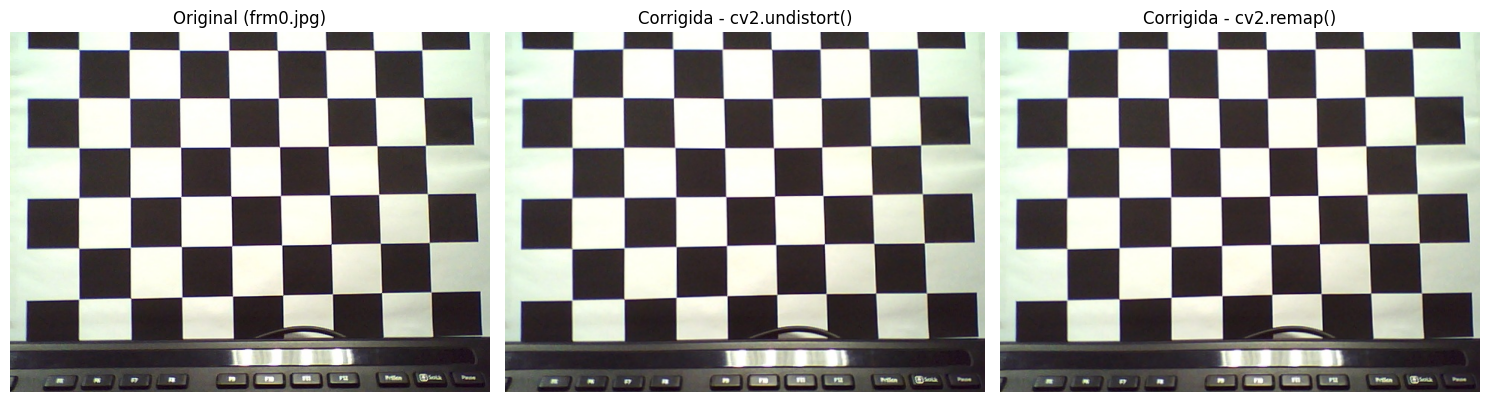

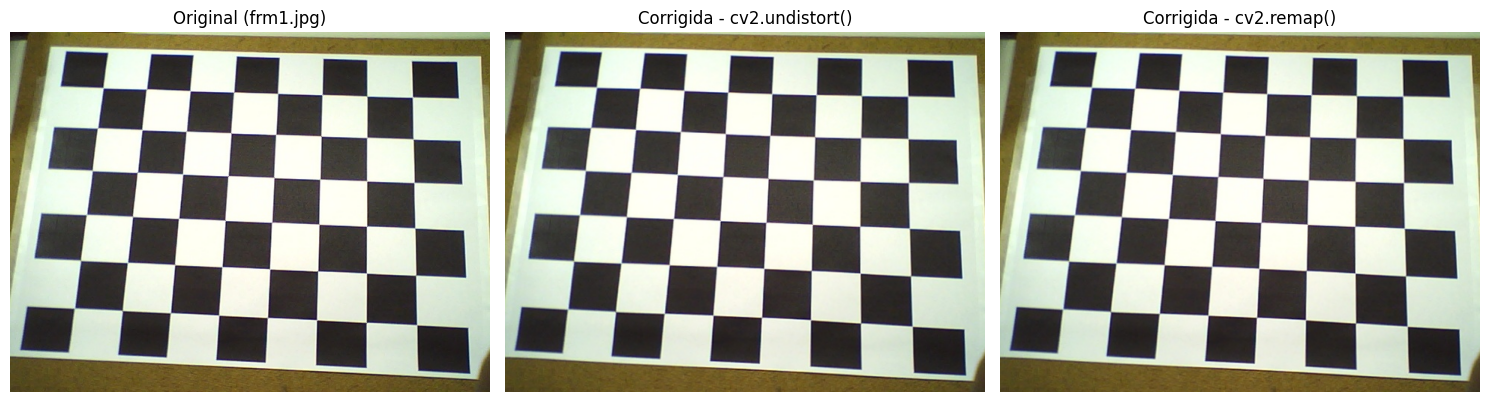

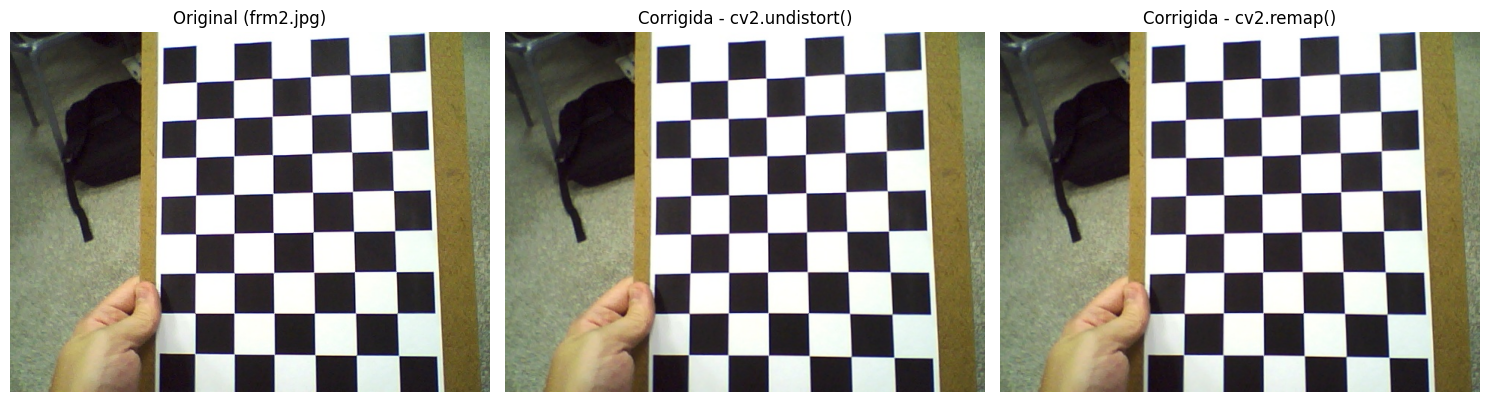

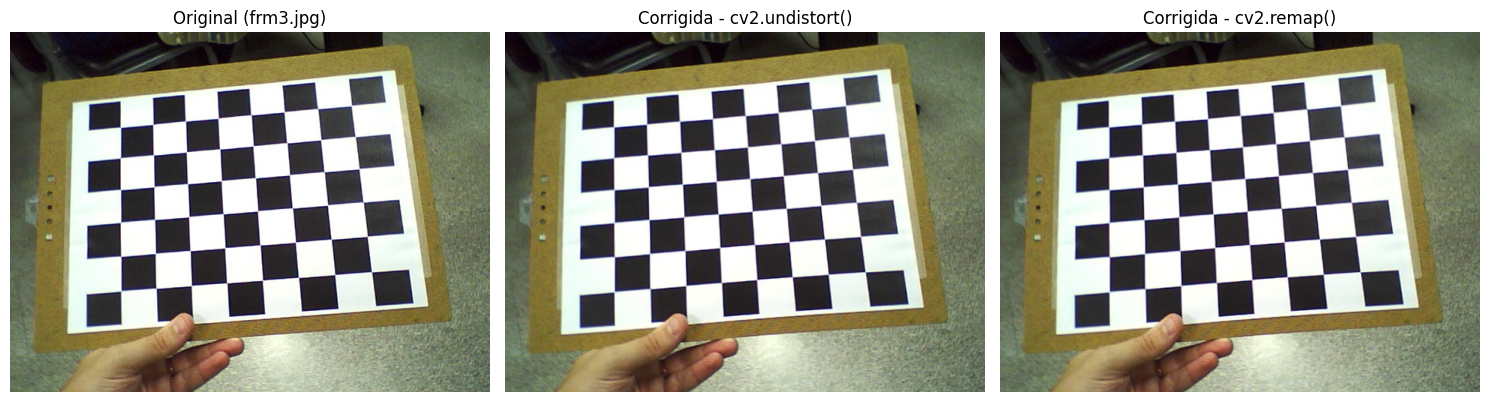

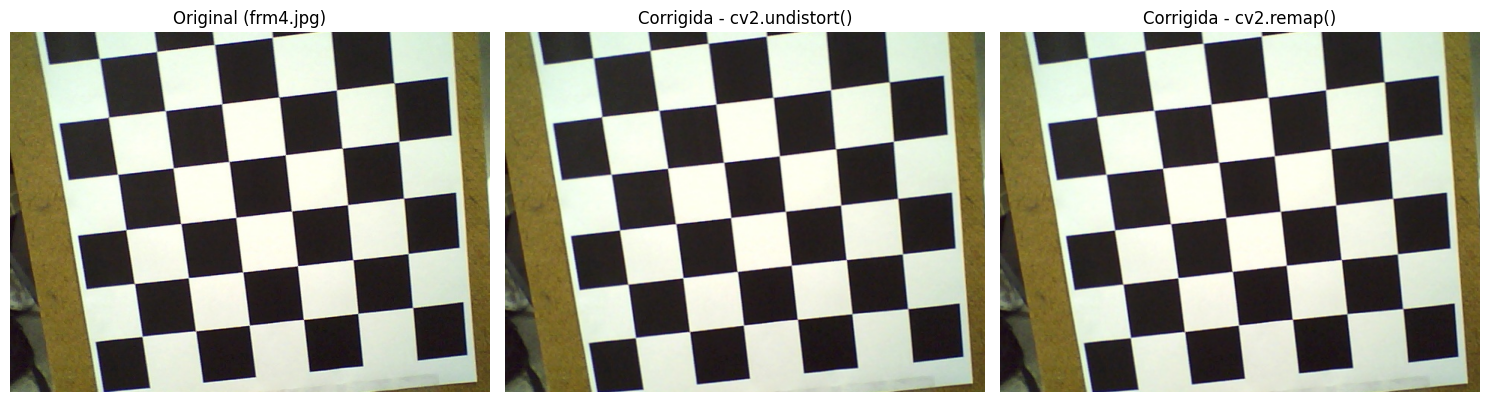

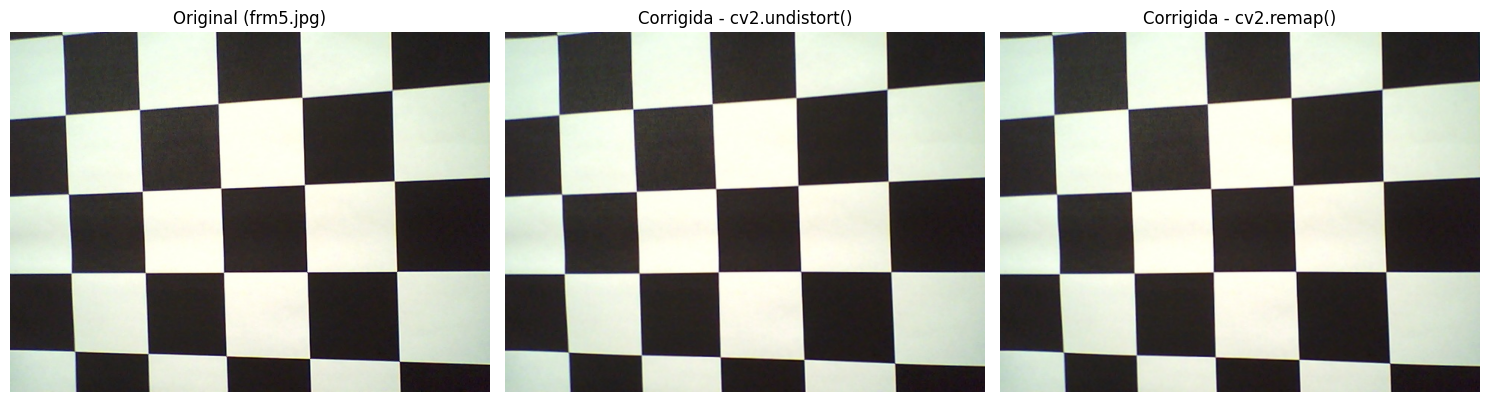

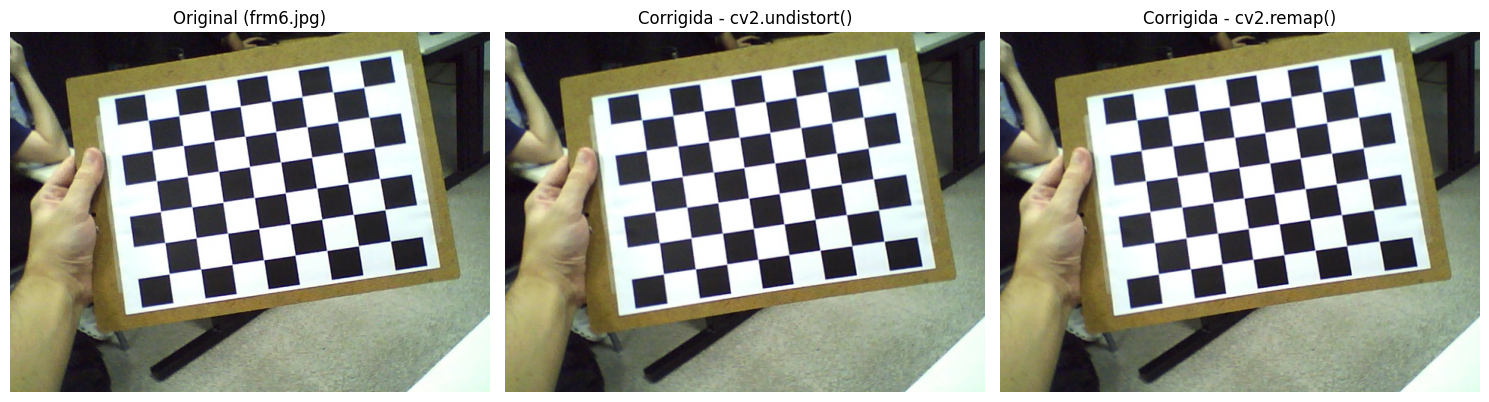

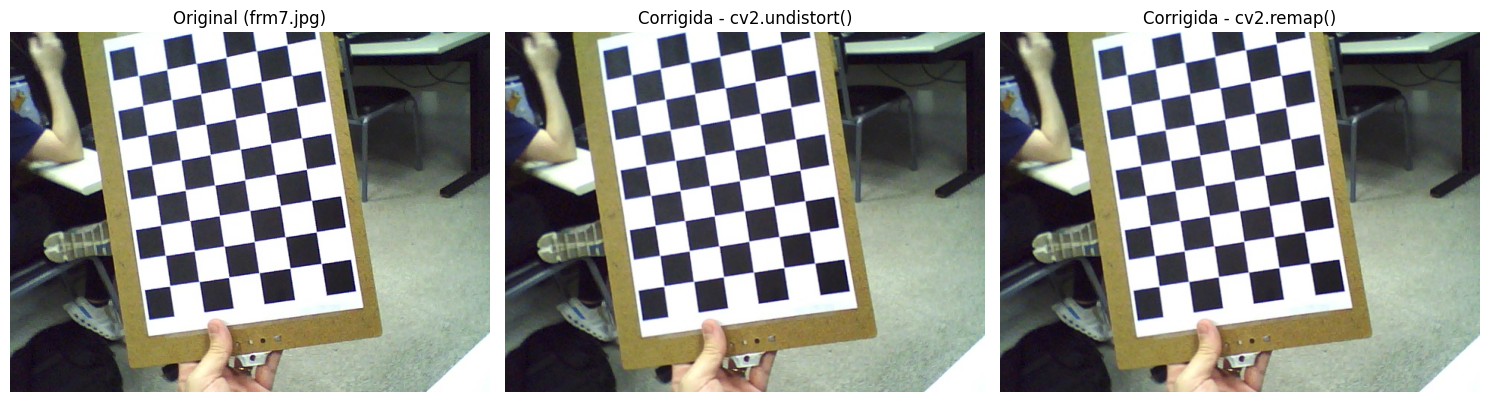

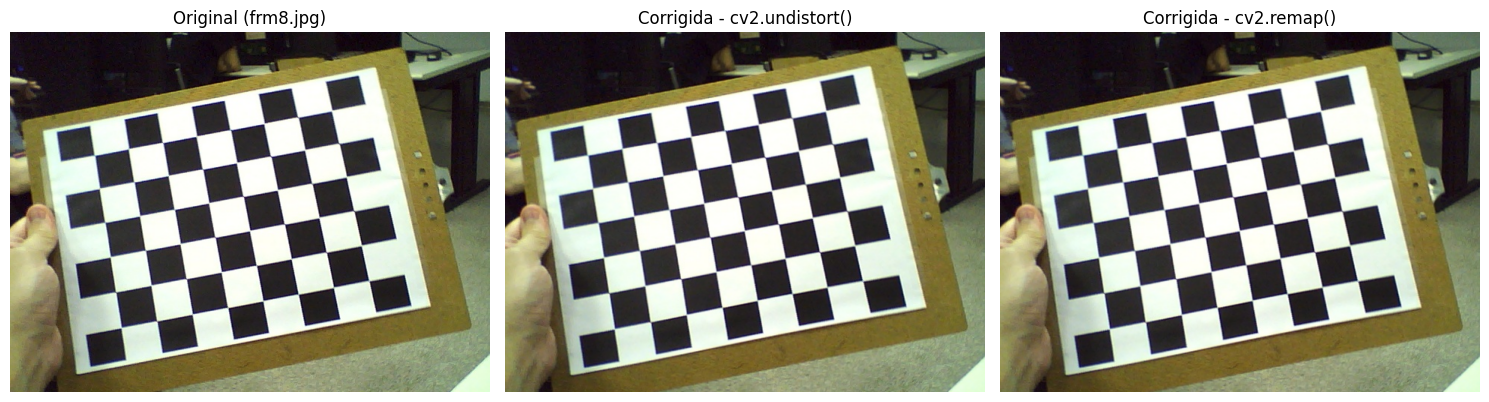

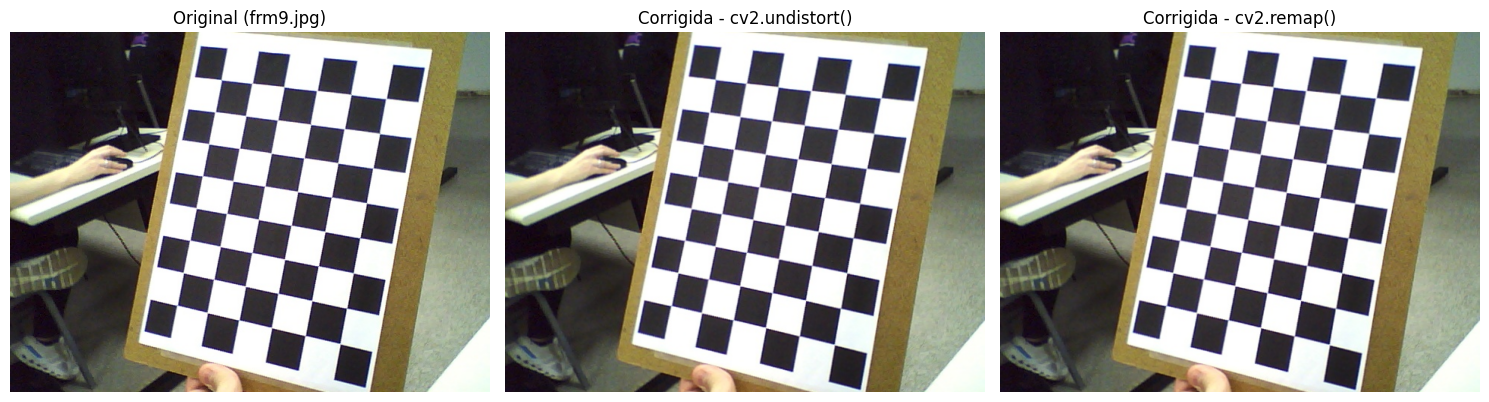

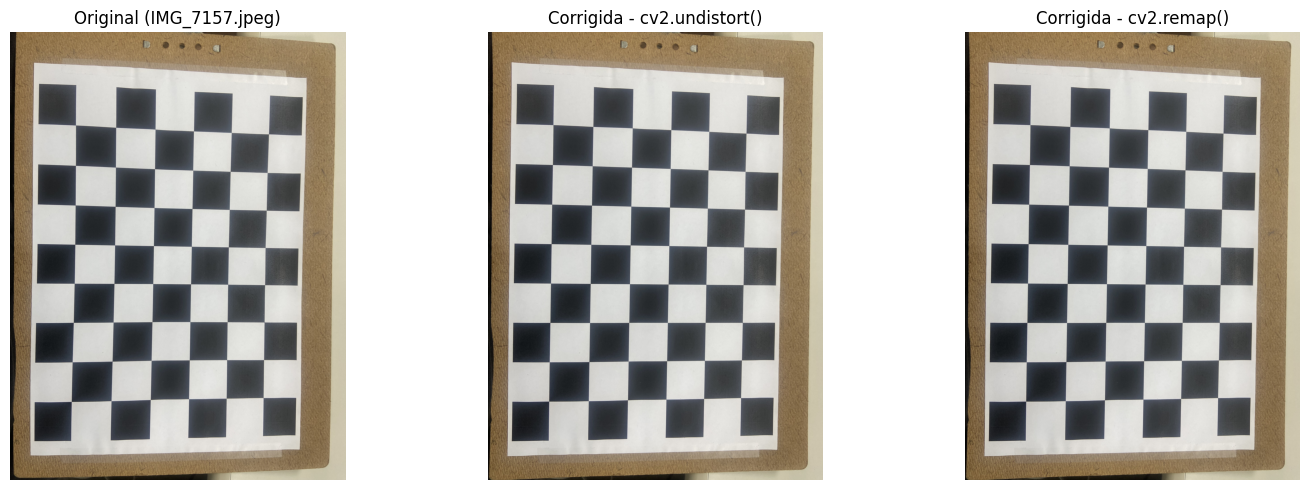

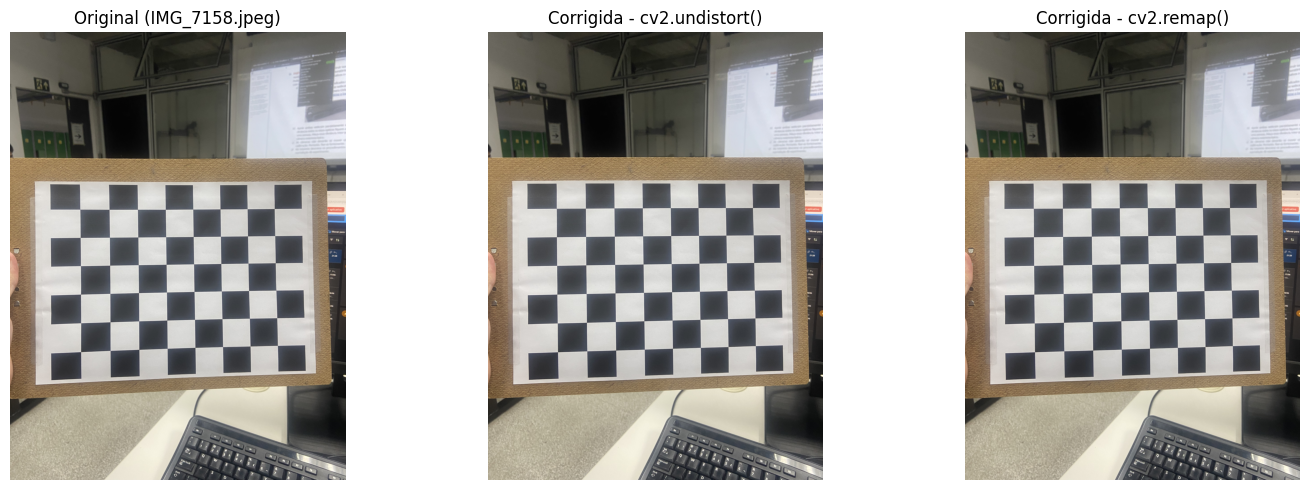

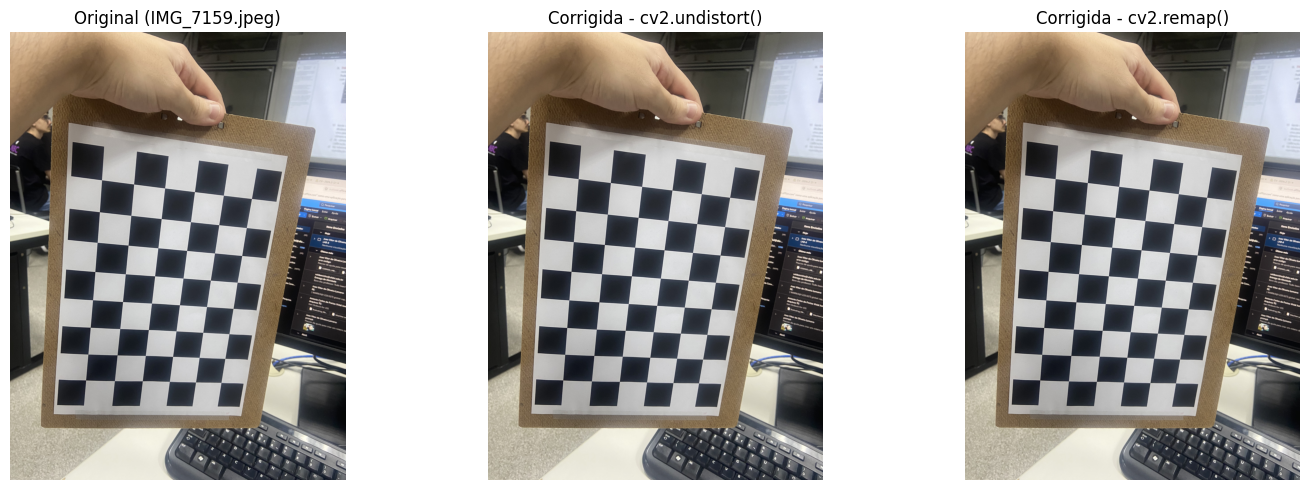

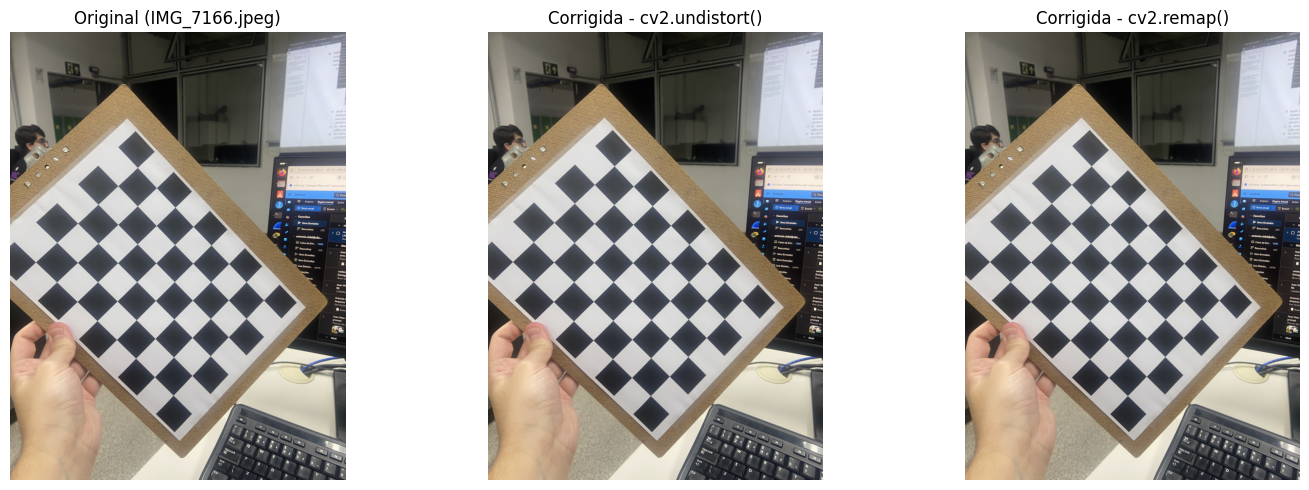

In [14]:
# Correção de distorção usando as calibrações dos itens B (webcam, mtx/dist)
# e C (segunda câmera, mtx_c/dist_c), consumindo as imagens de cada câmera

import cv2
import numpy as np
import glob
import matplotlib.pyplot as plt


def corrigir_distorcao(fname, mtx_cam, dist_cam):
    img = cv2.imread(fname)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img = img.shape[:2]

    # (i) Refinar a matriz da câmera com um parâmetro de escala livre
    newcameramtx, roi = cv2.getOptimalNewCameraMatrix(
        mtx_cam, dist_cam, (w_img, h_img), 1, (w_img, h_img)
    )

    # (ii) Correção de distorção com cv2.undistort()
    dst_undistort = cv2.undistort(img, mtx_cam, dist_cam, None, newcameramtx)
    x, y, w_roi, h_roi = roi
    if w_roi > 0 and h_roi > 0:
        dst_undistort = dst_undistort[y:y + h_roi, x:x + w_roi]

    # (iii) Correção de distorção via remapping, com cv2.remap()
    mapx, mapy = cv2.initUndistortRectifyMap(
        mtx_cam, dist_cam, None, newcameramtx, (w_img, h_img), 5
    )
    dst_remap = cv2.remap(img, mapx, mapy, cv2.INTER_LINEAR)
    if w_roi > 0 and h_roi > 0:
        dst_remap = dst_remap[y:y + h_roi, x:x + w_roi]

    # Exibindo original e as duas correções lado a lado
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    axs[0].imshow(img_rgb)
    axs[0].set_title(f'Original ({fname})')
    axs[0].axis('off')

    axs[1].imshow(cv2.cvtColor(dst_undistort, cv2.COLOR_BGR2RGB))
    axs[1].set_title('Corrigida - cv2.undistort()')
    axs[1].axis('off')

    axs[2].imshow(cv2.cvtColor(dst_remap, cv2.COLOR_BGR2RGB))
    axs[2].set_title('Corrigida - cv2.remap()')
    axs[2].axis('off')

    plt.tight_layout()
    plt.show()


# Imagens da webcam (calibrada no item B) - pelo menos 2 por aluno da equipe
imagens_webcam = sorted(glob.glob('frm*.jpg'))
for fname in imagens_webcam:
    corrigir_distorcao(fname, mtx, dist)

# Imagens da segunda câmera pessoal (calibrada no item C) - pelo menos 2 por aluno
imagens_camera2 = sorted(glob.glob('IMG_*.jpeg'))
for fname in imagens_camera2:
    corrigir_distorcao(fname, mtx_c, dist_c)


**Análise da correção de distorção radial.** Comparando as imagens lado a lado, o
efeito da correção fica visível principalmente **nas bordas**: nas imagens originais,
as linhas do tabuleiro que deveriam ser retas aparecem levemente **curvadas** perto
das extremidades (o abaulamento típico da distorção *barrel*); após a correção, essas
linhas ficam **mais retas**, e a grade do xadrez recupera sua geometria regular. Como
consequência do modelo, as imagens corrigidas também aparecem ligeiramente
**recortadas/reescaladas** nas bordas — resultado do reprojetamento e do corte pela
*ROI* devolvida por `getOptimalNewCameraMatrix()`.

Os **dois métodos** (`undistort` e `remap`) produzem resultados **visualmente
idênticos**, o que é esperado: `cv2.undistort()` é, na prática, um atalho que
internamente calcula os mesmos mapas de reprojeção usados explicitamente por
`initUndistortRectifyMap` + `remap`. A diferença é de eficiência — quando é preciso
corrigir **muitos quadros seguidos** (por exemplo, um vídeo em tempo real), vale a
pena calcular os mapas **uma única vez** e reaplicá-los com `remap` a cada quadro,
em vez de refazer todo o cálculo com `undistort`. O efeito da correção é mais sutil
nas fotos do **celular**, coerente com seus coeficientes de distorção menores
observados no item (C).

## 4. Análise e discussão

Reunindo os resultados dos quatro itens, o laboratório permitiu observar na prática
a diferença entre parâmetros **intrínsecos** e **extrínsecos** e o efeito da
**distorção de lente**.

**Sobre os intrínsecos (K).** Nas três calibrações, a matriz $K$ apresentou sempre
*skew* nulo e *aspect ratio* ≈ 1, confirmando que os sensores têm pixels quadrados e
eixos ortogonais. O ponto principal ficou sempre próximo do centro da respectiva
imagem, e a distância focal em pixels acompanhou a **resolução** de cada câmera
(≈ 560 px na webcam de baixa resolução, ≈ 3140 px no celular de alta resolução) — um
bom lembrete de que a focal em pixels só faz sentido quando comparada ao tamanho da
imagem.

**Sobre os extrínsecos (R, t).** O fato de a calibração devolver um par $(R, t)$ por
imagem evidencia a separação entre "o que é da câmera" e "o que é da cena": $K$ e a
distorção são estimados **uma vez** (são fixos), enquanto $R$ e $t$ descrevem a
**pose** — a relação entre o sistema do tabuleiro e o da câmera — que muda a cada
foto. Essa é exatamente a informação que, em robótica, permitiria a uma câmera
saber sua orientação e posição em relação a um objeto de referência.

**Sobre a distorção (dist) e sua correção.** Vimos que a webcam apresentou distorção
mais acentuada que o celular, e que a correção (item D) endireita as linhas curvadas
das bordas. Isso tem impacto direto em aplicações que dependem de medidas
geométricas: sem corrigir a distorção, um sistema de visão cometeria erros
sistemáticos maiores justamente longe do centro da imagem.

**Aplicação no trabalho final.** A calibração é um pré-requisito para praticamente
qualquer aplicação métrica de visão. Conectando com os laboratórios anteriores (SIFT,
homografia, mosaico e o par estéreo com duas webcams), uma câmera calibrada é o que
permitiria evoluir de um simples casamento de pontos para **medidas reais** — por
exemplo, estimar profundidade em um par estéreo, medir dimensões de peças em uma
**inspeção industrial** ou dar a um robô a capacidade de se localizar em relação a
marcadores. Em todos esses casos, os parâmetros $K$ e $dist$ obtidos aqui seriam o
ponto de partida.


## 5. Conclusões

O laboratório cumpriu seus objetivos: entendemos os conceitos de parâmetros
**intrínsecos** e **extrínsecos** e realizamos, na prática, a calibração de câmeras
pelo método do tabuleiro de xadrez no OpenCV.

Nos quatro itens, (A) reproduzimos a calibração com as imagens de exemplo e
interpretamos o significado de $K$, $R$, $t$ e $dist$; (B) calibramos nossa própria
webcam com 20 imagens, obtendo *focal length* ≈ (562, 560) px, *aspect ratio* ≈ 1,
*skew* nulo e ponto principal próximo do centro, e explicamos por que há um par
$(R, t)$ por imagem; (C) calibramos uma segunda câmera (celular) e comparamos as
duas, entendendo por que a focal em pixels é muito maior em uma câmera de alta
resolução; e (D) corrigimos a distorção de imagens reais com `undistort` e `remap`,
observando o endireitamento das linhas nas bordas.

O principal aprendizado foi ver, de forma concreta, como a calibração **separa** as
características fixas da câmera das poses variáveis da cena, e como a correção de
distorção recupera a geometria correta da imagem — uma base indispensável para
aplicações métricas de Visão Computacional, como visão estéreo, reconstrução 3D e
robótica.


## 6. Referências

1. LearnOpenCV — *Geometry of Image Formation*.
   https://learnopencv.com/geometry-of-image-formation/
2. LearnOpenCV — *Camera Calibration using OpenCV*.
   https://learnopencv.com/camera-calibration-using-opencv/
3. OpenCV — *Camera Calibration* (atenção à distorção radial das lentes).
   https://docs.opencv.org/4.x/dc/dbb/tutorial_py_calibration.html
4. BOUGUET, J.-Y. *Camera Calibration Toolbox for Matlab*.
   http://robots.stanford.edu/cs223b04/JeanYvesCalib/
5. *Pinhole camera model* — Wikipedia.
   https://en.wikipedia.org/wiki/Pinhole_camera_model
6. ZHANG, Z. *A Flexible New Technique for Camera Calibration*. IEEE Transactions on
   Pattern Analysis and Machine Intelligence, v. 22, n. 11, p. 1330-1334, 2000.
7. SZELISKI, R. *Computer Vision: Algorithms and Applications*. 2ª ed. Springer, 2022.
8. Roteiro do Laboratório 4 — ESZA019 Visão Computacional, UFABC, 2026.2 (v.2).
